In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("plots", exist_ok=True)

(569, 31)
target
1    357
0    212
Name: count, dtype: int64


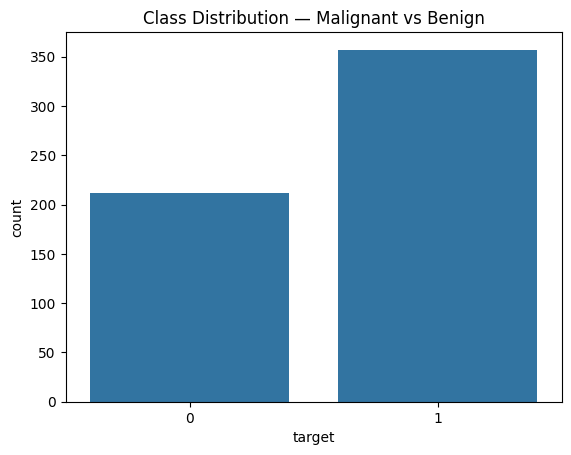

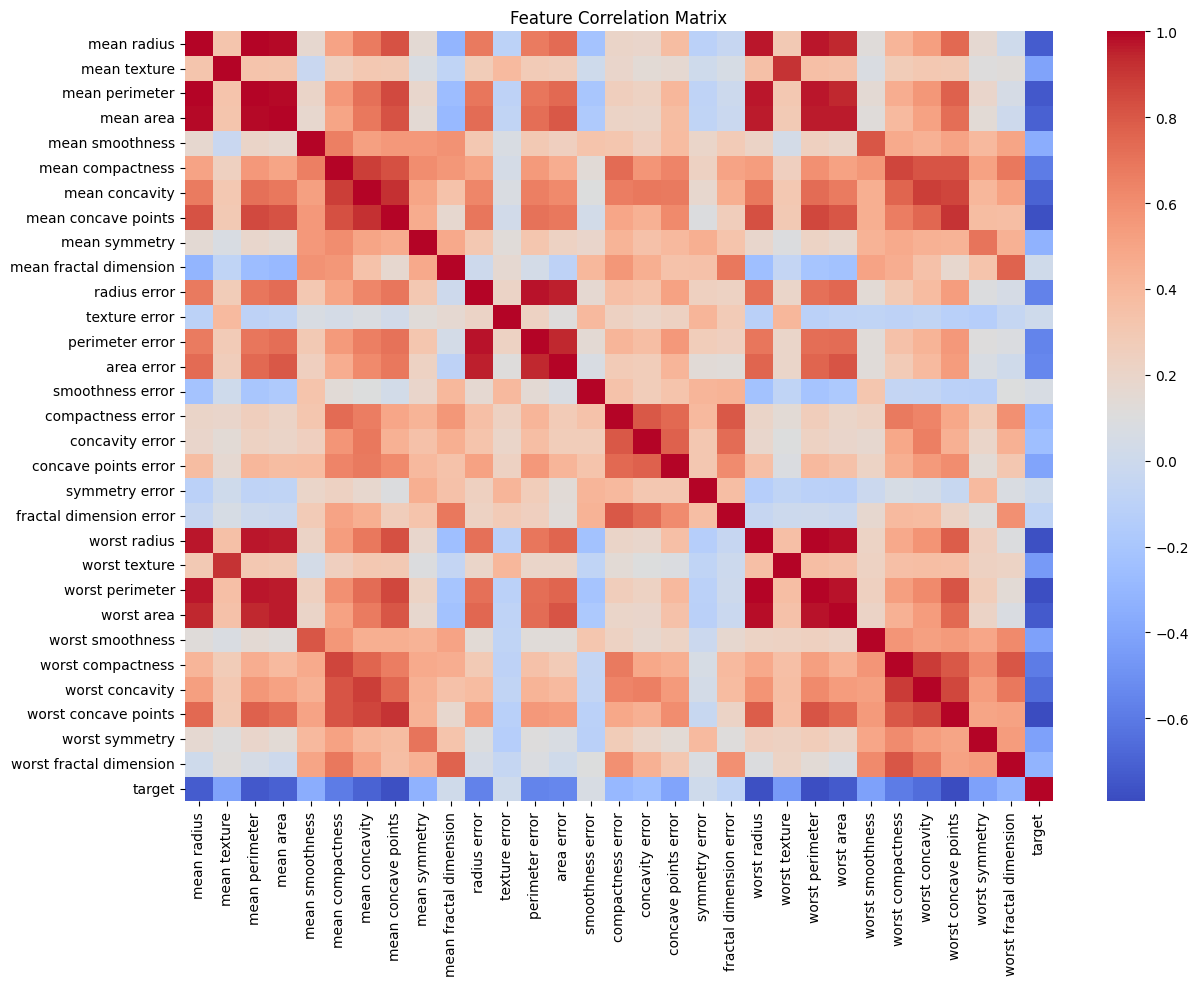

In [2]:
# ============================================================
# SECTION 1: Load Data & EDA
# ============================================================

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(df.shape)
print(df['target'].value_counts())
df.describe()

# Plot class distribution
sns.countplot(x='target', data=df)
plt.title('Class Distribution — Malignant vs Benign')
plt.savefig('plots/class_distribution.png',dpi=300)

# Correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix')
plt.savefig('plots/correlation_heatmap.png',dpi=300)

In [3]:
# ============================================================
# SECTION 2: Preprocessing
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# ============================================================
# SECTION 3: Model 1 — Logistic Regression (Baseline)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

print("Logistic Regression:")
print(classification_report(y_test, lr_preds))
print(f"AUC-ROC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]):.4f}")

Logistic Regression:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

AUC-ROC: 0.9954


In [5]:
# ============================================================
# SECTION 4: Model 2 — Random Forest
# ============================================================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest:")
print(classification_report(y_test, rf_preds))
print(f"AUC-ROC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}")

Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

AUC-ROC: 0.9937


In [6]:
# ============================================================
# SECTION 5: Model 3 — XGBoost
# ============================================================
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42,
                     eval_metric='logloss', use_label_encoder=False)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("XGBoost:")
print(classification_report(y_test, xgb_preds))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}")

XGBoost:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

AUC-ROC: 0.9901


C:\Users\koush\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:23:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                 Model   AUC-ROC
0  Logistic Regression  0.995370
1        Random Forest  0.993717
2              XGBoost  0.990079


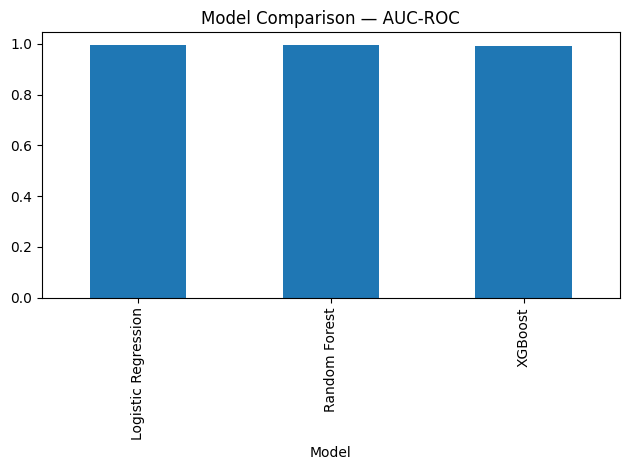

In [7]:
# ============================================================
# SECTION 6: Model Comparison
# ============================================================
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'AUC-ROC': [
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
    ]
})
print(results)
results.plot(x='Model', y='AUC-ROC', kind='bar', legend=False)
plt.title('Model Comparison — AUC-ROC')
plt.tight_layout()
plt.savefig('plots/model_comparison.png',dpi=300)

In [9]:
# ============================================================
# SECTION 7: SHAP Explainability
# ============================================================
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot — most important features overall
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig('plots/shap_summary.png',dpi=300, bbox_inches='tight')
plt.close()

# Force plot — explain one single prediction
shap.initjs()
shap.force_plot(explainer.expected_value,
                shap_values[0], X_test.iloc[0])